# MIG Quant Competition — Data Exploration

This notebook walks through the `dev_data_30.csv` dataset so you understand what your strategy receives.

**Dataset**: OHLCV data for 30 stocks.  
**Your strategy only sees the Open price** — but you can use all columns here for research.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette('husl')

pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 1. Load the dataset


We use pandas data-frames to load the data from the CSV as we add the asset "Ticker" and the price "Date" as the index into the Dataframe. This allows us to index the dataframe depending on what asset we want to look at. We can also see that every asset has  *daily* price data for `Open`, `High`, `Low`, `Close`, `Adj Close`, and `Volume`.

In [4]:
# Load the CSV — adjust the path if running from a different directory
df = pd.read_csv('../dev_data_30.csv', parse_dates=['Date'], date_format='%m/%d/%y', thousands=',')


# set indexes 
df.set_index(["Ticker", "Date"], inplace=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (30180, 6)
Columns: ['Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume']

First 5 rows:


Open   High    Low  Close  Adj. Close   Volume
Ticker Date                                                       
A      2017-03-15 6.7000 6.7700 5.9600 6.0600      6.0600  6970100
       2017-03-16 6.1000 6.2000 5.7500 5.7600      5.7600  3652400
       2017-03-17 5.8100 5.8900 5.6500 5.8000      5.8000  3477100
       2017-03-20 5.8500 5.8600 5.5100 5.5700      5.5700  2484100
       2017-03-21 5.5600 5.6000 5.4200 5.4600      5.4600  1798400

In [5]:
# we can see that our dataframe (df) has index values of (Ticker, Date)
df.index

MultiIndex([( 'A', '2017-03-15'),
            ( 'A', '2017-03-16'),
            ( 'A', '2017-03-17'),
            ( 'A', '2017-03-20'),
            ( 'A', '2017-03-21'),
            ( 'A', '2017-03-22'),
            ( 'A', '2017-03-23'),
            ( 'A', '2017-03-24'),
            ( 'A', '2017-03-27'),
            ( 'A', '2017-03-28'),
            ...
            ('AD', '2021-03-01'),
            ('AD', '2021-03-02'),
            ('AD', '2021-03-03'),
            ('AD', '2021-03-04'),
            ('AD', '2021-03-05'),
            ('AD', '2021-03-08'),
            ('AD', '2021-03-09'),
            ('AD', '2021-03-10'),
            ('AD', '2021-03-11'),
            ('AD', '2021-03-12')],
           names=['Ticker', 'Date'], length=30180)

In [6]:
# How many unique tickers?
tickers = sorted(df.index.get_level_values('Ticker').unique())
print(f'Unique tickers: {len(tickers)}')
print(tickers)

Unique tickers: 30
['A', 'AA', 'AB', 'AC', 'AD', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [7]:
# Date range
print('Date range:', df.index.get_level_values('Date').min(), '->', df.index.get_level_values('Date').max())

Date range: 2017-03-15 00:00:00 -> 2021-03-12 00:00:00


## 2. Build the prices matrix

This is exactly what `get_actions(prices)` receives — shape `(num_stocks, num_days)`, Open price only.

In [8]:
# Extract all Date values from the MultiIndex to compute the overall date range
prices_df = df['Open'].unstack(level='Date').sort_index()

# Forward-fill any missing days, then drop remaining NaN columns 
#(there should not be any in our data but this is good practice)
prices_df = prices_df.ffill(axis=1).dropna(axis=1)

prices = prices_df.values  # shape: (num_stocks, num_days)
print('prices matrix shape:', prices.shape)  # should be ~(30, N)
print('Row labels (tickers):', prices_df.index.tolist())

prices matrix shape: (30, 1006)
Row labels (tickers): ['A', 'AA', 'AB', 'AC', 'AD', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [9]:
# If we want to look at the close price data for asset "A"
A_close_data = df.loc["A"]["Close"]
A_close_data

Date
2017-03-15    6.0600
2017-03-16    5.7600
2017-03-17    5.8000
2017-03-20    5.5700
2017-03-21    5.4600
               ...  
2021-03-08   37.1200
2021-03-09   43.4000
2021-03-10   44.2200
2021-03-11   49.6500
2021-03-12   49.2100
Name: Close, Length: 1006, dtype: float64

We can see that this data has index of "Date" and the close price data doesn't actually have a column name but can be accessed with `A_close_data.values`

In [10]:
# We can access the dates and close values separately 
# in this case the index of the data has become only the dates column
print("Date index:", A_close_data.index)
print("Close price values:", A_close_data.values)

Date index: DatetimeIndex(['2017-03-15', '2017-03-16', '2017-03-17', '2017-03-20',
               '2017-03-21', '2017-03-22', '2017-03-23', '2017-03-24',
               '2017-03-27', '2017-03-28',
               ...
               '2021-03-01', '2021-03-02', '2021-03-03', '2021-03-04',
               '2021-03-05', '2021-03-08', '2021-03-09', '2021-03-10',
               '2021-03-11', '2021-03-12'],
              dtype='datetime64[us]', name='Date', length=1006, freq=None)
Close price values: [ 6.06  5.76  5.8  ... 44.22 49.65 49.21]


## 3. Price distributions

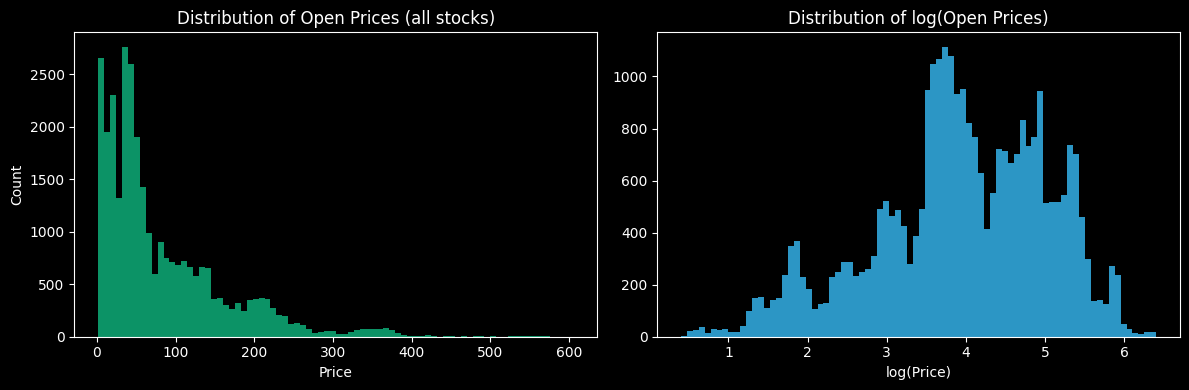

In [11]:
# Distribution of all Open prices across all stocks
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prices.flatten(), bins=80, color='#10b981', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution of Open Prices (all stocks)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log(prices.flatten()), bins=80, color='#38bdf8', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution of log(Open Prices)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

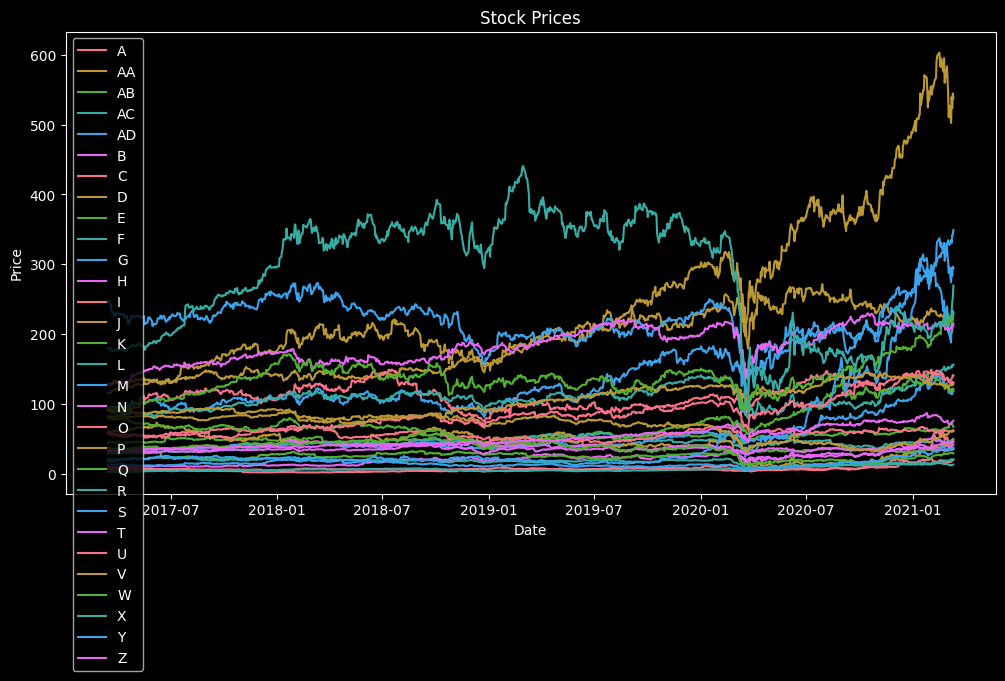

In [12]:
# We can plot all the symbols like below
tickers = sorted(df.index.get_level_values('Ticker').unique())

plt.figure(figsize=(12, 6))

for ticker in tickers:
    stock_close_data = df.loc[ticker]["Close"]
    plt.plot(stock_close_data.index,stock_close_data.values, label=f'{ticker}')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Prices')
plt.legend()
plt.show()

## 4. Price series — a few stocks

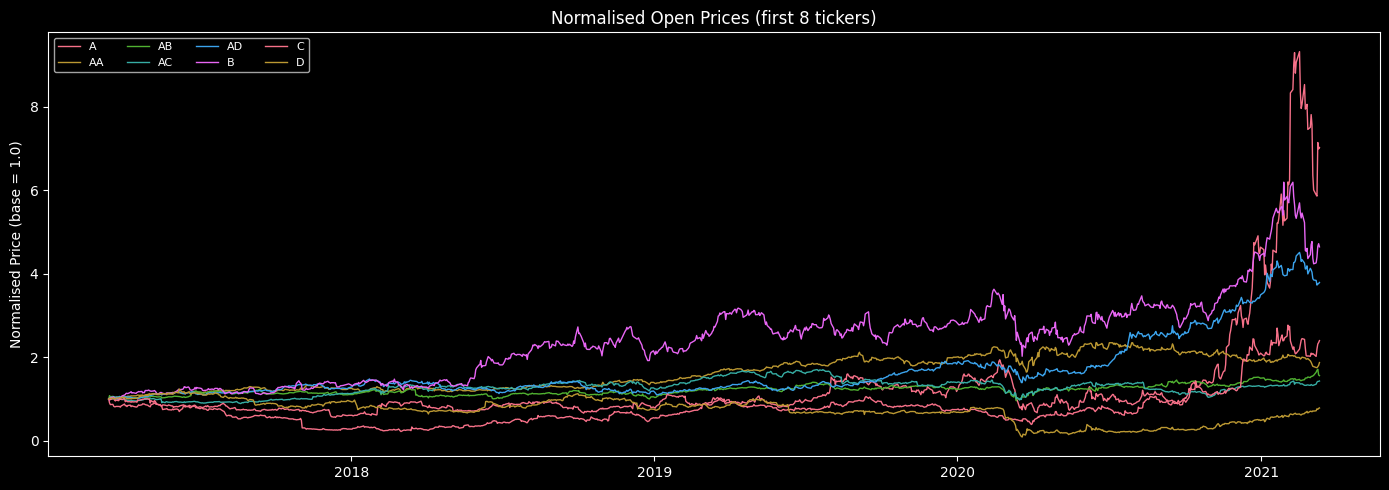

In [13]:
# Plot normalised price series for the first 8 tickers
sample_tickers = tickers[:8]
dates = prices_df.columns

fig, ax = plt.subplots(figsize=(14, 5))

for ticker in sample_tickers:
    series = prices_df.loc[ticker].values
    normalised = series / series[0]  # start at 1.0
    ax.plot(dates, normalised, linewidth=1, label=ticker)

ax.set_title('Normalised Open Prices (first 8 tickers)')
ax.set_ylabel('Normalised Price (base = 1.0)')
ax.legend(fontsize=8, ncol=4)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 5. Daily returns

Mean daily return (across all stocks): 0.0006707013495822168
Std  daily return (across all stocks): 0.02695650340626412


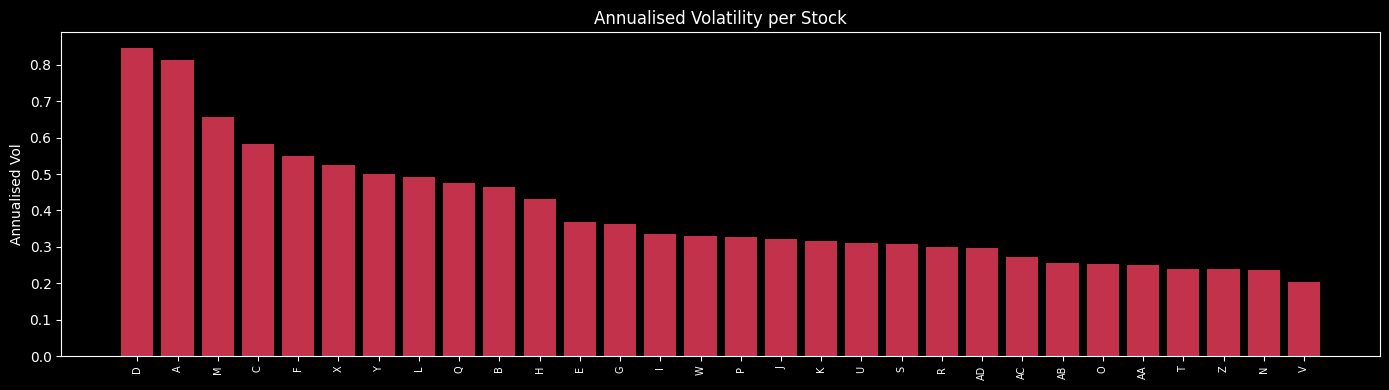

In [14]:
# Daily log returns for all stocks
log_returns = np.diff(np.log(prices), axis=1)  # shape: (num_stocks, num_days - 1)

print('Mean daily return (across all stocks):', log_returns.mean())
print('Std  daily return (across all stocks):', log_returns.std())

# Per-stock annualised volatility
ann_vol = log_returns.std(axis=1) * np.sqrt(252)
vol_df = pd.Series(ann_vol, index=prices_df.index).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vol_df.index, vol_df.values, color='#f43f5e', alpha=0.8)
ax.set_title('Annualised Volatility per Stock')
ax.set_ylabel('Annualised Vol')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 6. Correlation matrix

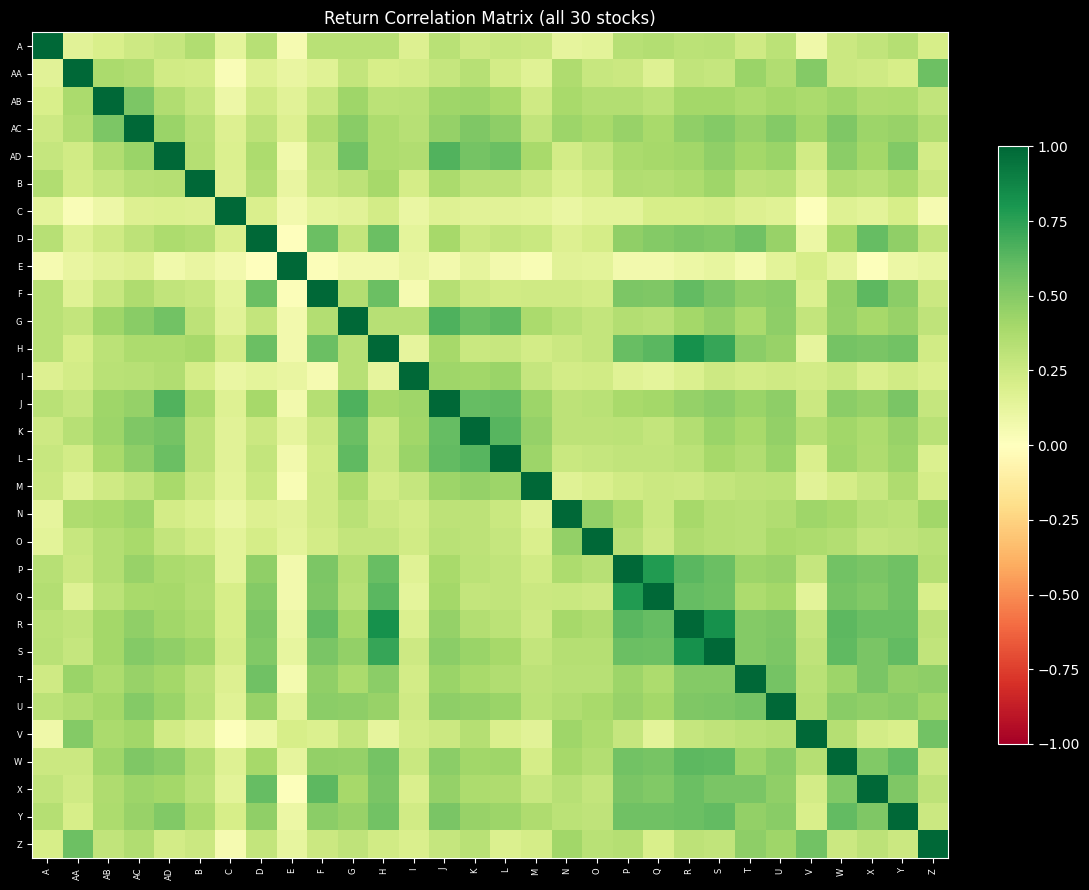

Average pairwise correlation: 0.3351
Min pairwise correlation:     0.0059
Max pairwise correlation:     0.8263


In [15]:
# Pairwise correlation of daily returns
corr_matrix = np.corrcoef(log_returns)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title('Return Correlation Matrix (all 30 stocks)')
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=90, fontsize=6)
ax.set_yticklabels(tickers, fontsize=6)
plt.tight_layout()
plt.show()

# Off-diagonal stats
off_diag = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
print(f'Average pairwise correlation: {off_diag.mean():.4f}')
print(f'Min pairwise correlation:     {off_diag.min():.4f}')
print(f'Max pairwise correlation:     {off_diag.max():.4f}')

## 7. Volume analysis

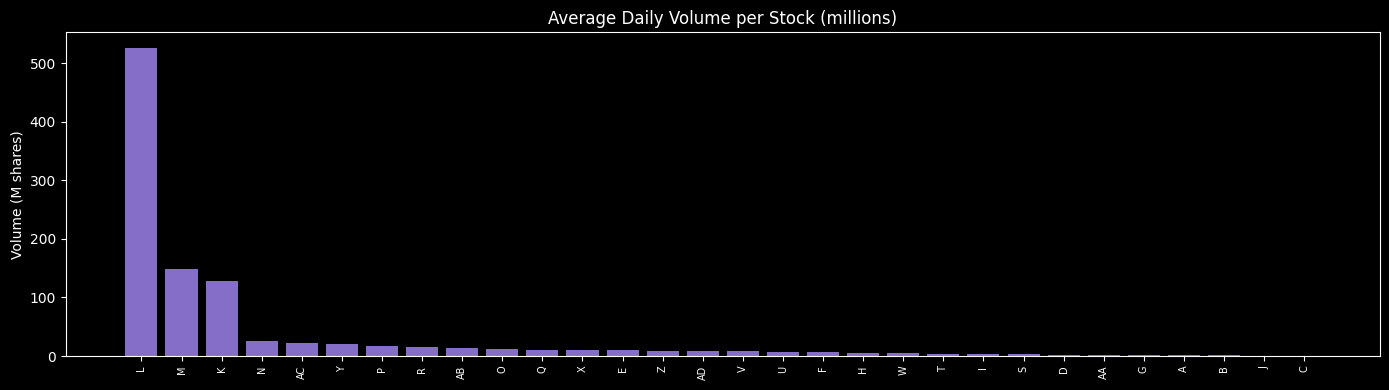

In [16]:
# Average daily volume per ticker
avg_volume = df.groupby('Ticker')['Volume'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(avg_volume.index, avg_volume.values / 1e6, color='#a78bfa', alpha=0.8)
ax.set_title('Average Daily Volume per Stock (millions)')
ax.set_ylabel('Volume (M shares)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 8. Simple technical feature: 20-day rolling momentum

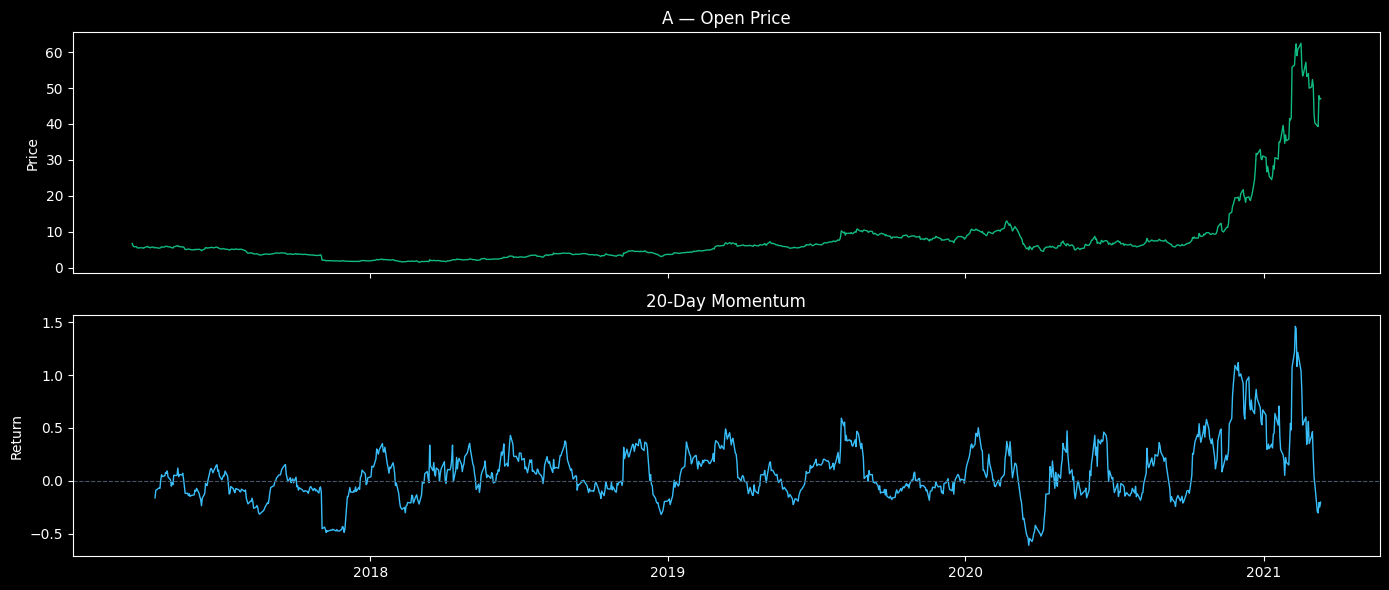

In [17]:
# 20-day rolling return (momentum signal)
# Using the first stock as an example
example_ticker = tickers[0]
series = prices_df.loc[example_ticker].values
momentum_20 = np.full_like(series, np.nan)
for t in range(20, len(series)):
    momentum_20[t] = (series[t] - series[t - 20]) / series[t - 20]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(dates, series, color='#10b981', linewidth=1)
ax1.set_title(f'{example_ticker} — Open Price')
ax1.set_ylabel('Price')

ax2.plot(dates, momentum_20, color='#38bdf8', linewidth=1)
ax2.axhline(0, color='#475569', linewidth=0.8, linestyle='--')
ax2.set_title('20-Day Momentum')
ax2.set_ylabel('Return')
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 9. Convert to Numpy Arrays for Greater Analysis

It can also be useful to put the stocks prices into a Numpy array so it is easier to manipulate. Below we will do that with the stock prices. Also note here that we sort the tickers so that the first index will refer to `A`, the second to `B` and so on.

In [18]:
tickers = sorted(df.index.get_level_values('Ticker').unique())

close_prices = []

for ticker in tickers:
    stock_close_data = df.loc[ticker]["Close"]
    close_prices.append(stock_close_data.values)

close_prices = np.stack(close_prices)


print(f"Tickers {tickers}")
print(f"close_prices shape: {close_prices.shape}") # (30, 1258)
print(f"close_prices:\n{close_prices}")

Tickers ['A', 'AA', 'AB', 'AC', 'AD', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
close_prices shape: (30, 1006)
close_prices:
[[  6.06   5.76   5.8  ...  44.22  49.65  49.21]
 [115.28 115.09 116.01 ... 204.42 213.9  215.2 ]
 [ 43.05  45.73  45.66 ...  72.12  67.41  67.16]
 ...
 [178.71 178.19 180.1  ... 245.34 252.   269.19]
 [ 12.89  12.82  12.76 ...  34.46  37.47  37.42]
 [ 32.97  32.47  32.56 ...  74.46  74.86  75.67]]


## 10. Arbitrage: Cointegration between stocks and baskets

**Statistical arbitrage** exploits mean-reverting spreads between assets. If a stock is cointegrated with a basket (linear combination) of other stocks, the spread between them is stationary — it deviates but reverts to a mean, creating trade opportunities.

**Approach:**
1. For each stock, use OLS to find the best-fit basket of all other stocks (hedge ratios).
2. Compute the spread (residual) and test for stationarity with the Augmented Dickey-Fuller (ADF) test.
3. A low ADF p-value (< 0.05) means the spread is stationary → potential arb opportunity.
4. Visualise the most promising spreads and their z-scores.

In [19]:
%pip install scikit-learn statsmodels

from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------------------------
# 1. For each stock, regress it on all other stocks to find the best hedge basket,
#    then test whether the residual (spread) is stationary (ADF test).
# ---------------------------------------------------------------------------
close_df = df['Close'].unstack(level='Date').sort_index().ffill(axis=1).dropna(axis=1)
close_mat = close_df.values  # (30, num_days)

results = []

for i, target in enumerate(tickers):
    y = close_mat[i]
    X = np.delete(close_mat, i, axis=0).T  # (num_days, 29)

    # Split: fit hedge ratios on first 70%, test on full series to check stability
    split = int(len(y) * 0.7)
    reg = LinearRegression().fit(X[:split], y[:split])
    basket = reg.predict(X)
    spread = y - basket

    adf_stat, adf_pval, *_ = adfuller(spread, maxlag=20, autolag='AIC')

    # Spread half-life (mean reversion speed) via AR(1)
    spread_lag = spread[:-1]
    spread_diff = np.diff(spread)
    beta_ar = np.polyfit(spread_lag, spread_diff, 1)[0]
    half_life = -np.log(2) / beta_ar if beta_ar < 0 else np.inf

    hedge_tickers = [t for t in tickers if t != target]
    top_weights = sorted(zip(hedge_tickers, reg.coef_), key=lambda x: abs(x[1]), reverse=True)[:5]

    results.append({
        'target': target,
        'adf_stat': adf_stat,
        'adf_pval': adf_pval,
        'half_life': half_life,
        'spread_std': spread.std(),
        'top_weights': top_weights,
        'spread': spread,
        'basket': basket,
    })

# ---------------------------------------------------------------------------
# 2. Summary table — sort by ADF p-value (lower = more stationary = better)
# ---------------------------------------------------------------------------
summary = pd.DataFrame([{
    'Stock': r['target'],
    'ADF Stat': r['adf_stat'],
    'ADF p-val': r['adf_pval'],
    'Half-Life (days)': r['half_life'],
    'Spread Std': r['spread_std'],
    'Top Basket Weights': ', '.join(f"{t}:{w:+.3f}" for t, w in r['top_weights']),
} for r in results]).sort_values('ADF p-val')

print(f"Stocks with stationary spread (p < 0.05): "
      f"{(summary['ADF p-val'] < 0.05).sum()} / {len(tickers)}\n")
summary.head(15)

  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 31.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 24.1 MB/s eta 0:00:00 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 12.1 MB/s eta 0:00:00
Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Stocks with stationary spread (p < 0.05): 3 / 30



,Stock,ADF Stat,ADF p-val,Half-Life (days),Spread Std,Top Basket Weights
20,Q,-3.3602,0.0124,39.0446,7.6995,"L:+1.671, A:+1.336, Y:+0.793, B:-0.774, Z:-0.766"
14,K,-3.3546,0.0126,19.2739,4.9063,"L:+3.827, C:-1.732, H:-0.438, Z:+0.430, Y:-0.349"
6,C,-3.1298,0.0244,32.5499,2.0888,"L:+0.253, A:+0.240, B:+0.116, K:-0.111, Z:-0.106"
28,Y,-2.6821,0.0772,31.2582,2.6935,"L:-0.469, A:-0.248, N:-0.232, B:+0.195, C:-0.161"
11,H,-2.6576,0.0817,29.4549,2.3420,"L:-0.555, F:+0.335, R:+0.178, C:-0.165, E:+0.121"
8,E,-2.6169,0.0895,58.7063,8.1555,"L:-1.467, C:+1.232, A:-0.776, AB:-0.460, H:+0.407"
1,AA,-2.4635,0.1246,20.3327,12.4428,"Z:+1.876, L:-1.853, Y:+0.830, AC:+0.757, C:+0.665"
17,N,-2.4375,0.1314,64.4412,6.2126,"A:-0.466, Y:-0.434, B:+0.307, AC:+0.250, L:-0.239"
23,T,-2.4294,0.1336,35.3570,16.8179,"L:+8.271, C:-2.575, A:+1.591, H:+1.037, AD:-0.959"
15,L,-2.3603,0.1532,44.1364,1.0475,"C:+0.067, K:+0.065, AD:+0.052, B:+0.048, A:-0.045"


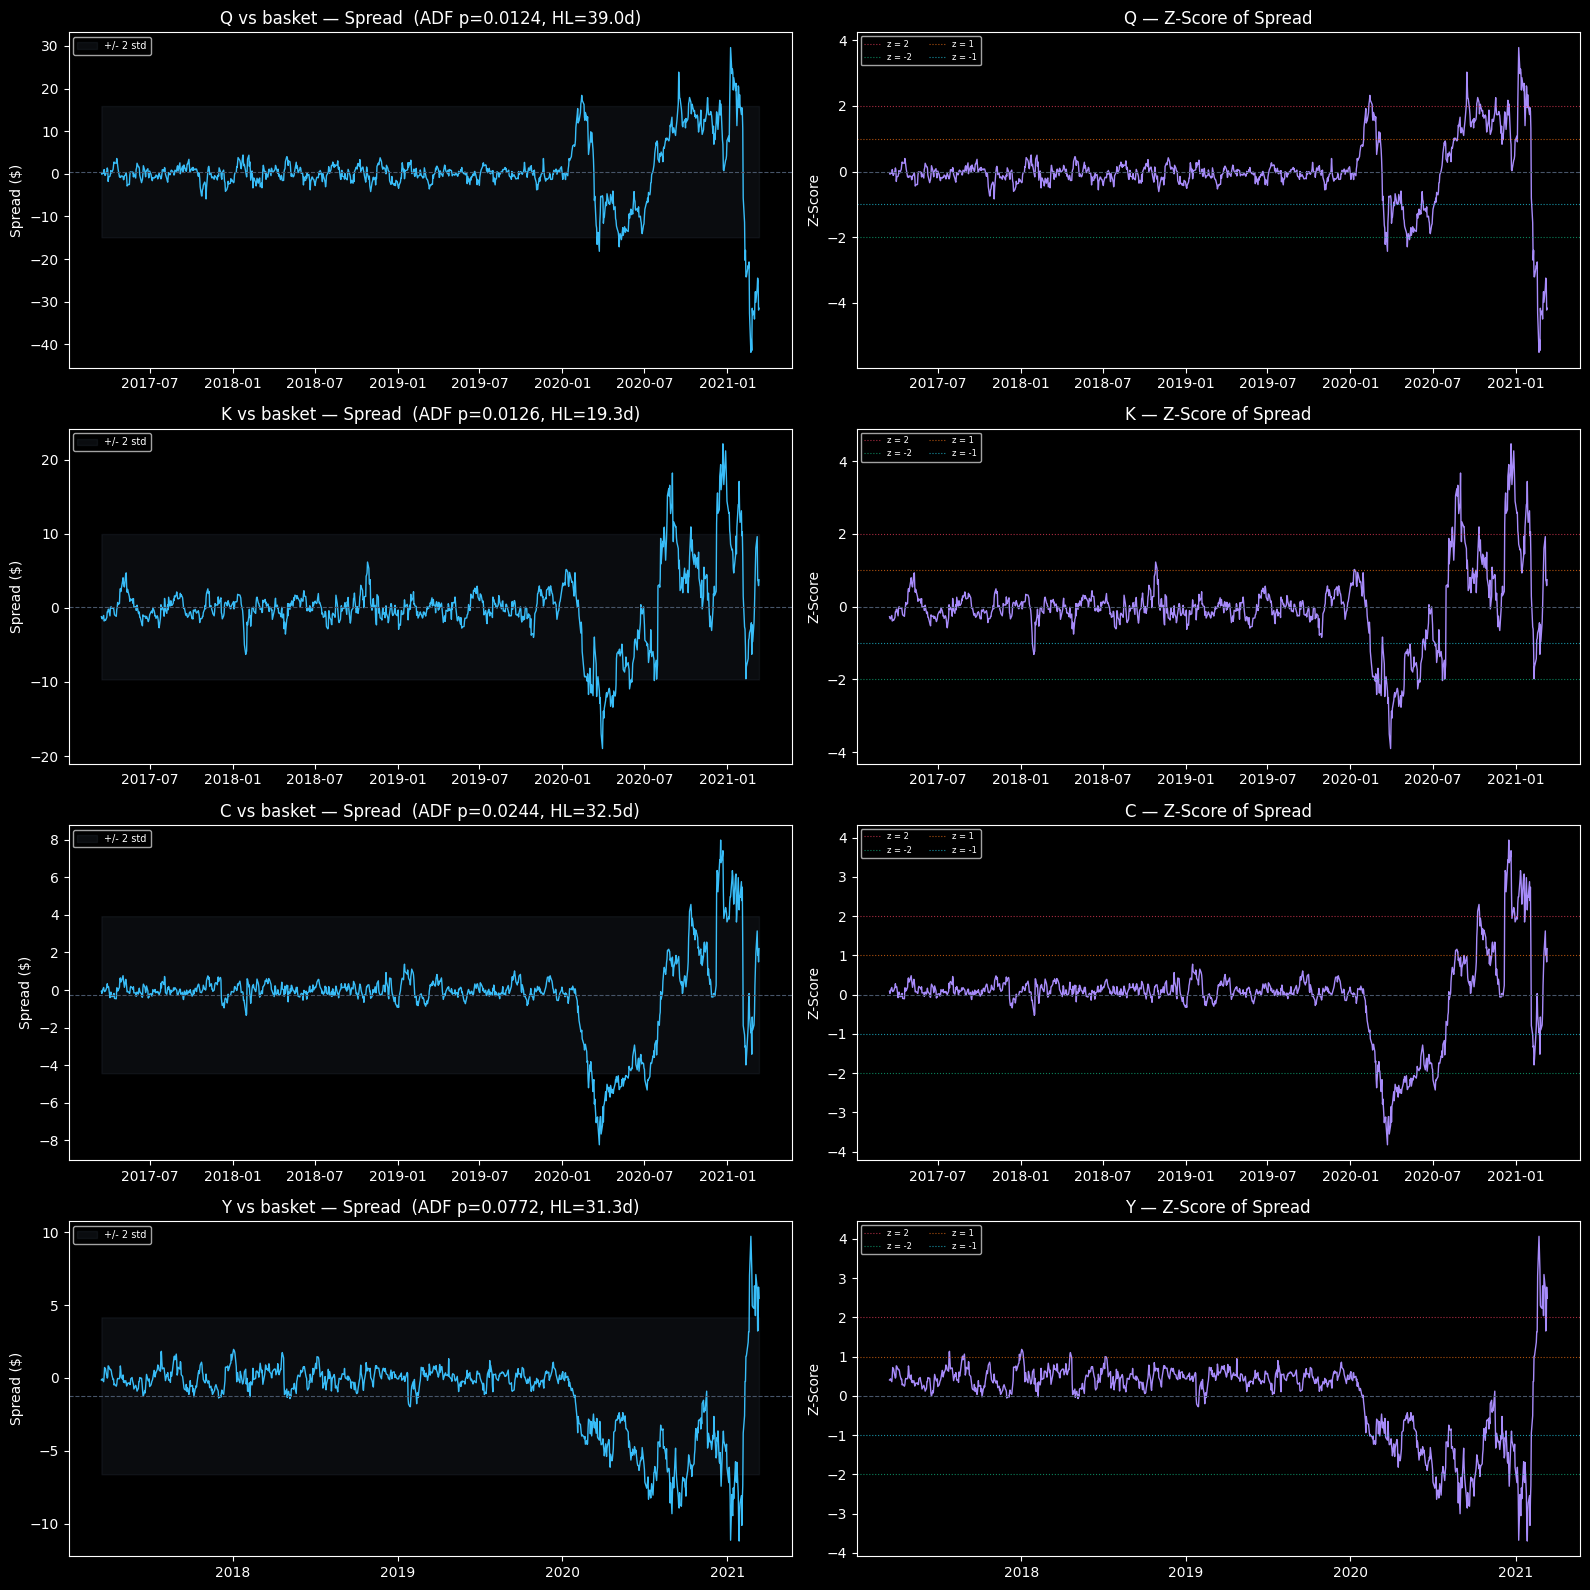


Cointegrated pairs (p < 0.05): 33 / 435


,Pair,Beta,ADF Stat,ADF p-val
1,AA / Q,-2.1016,-4.6394,0.0001
5,AB / G,0.0777,-4.5920,0.0001
3,AB / B,0.4836,-4.5630,0.0002
2,AB / AD,0.1765,-4.2956,0.0005
14,AB / Z,0.3080,-4.2894,0.0005
6,AB / J,0.0398,-4.0579,0.0011
16,B / U,0.3372,-3.9932,0.0014
12,AB / U,0.1825,-3.9878,0.0015
32,W / Y,3.7802,-3.7579,0.0034
31,T / V,1.0277,-3.7398,0.0036


In [20]:
# ---------------------------------------------------------------------------
# 3. Visualise the top 4 most stationary spreads and their z-scores
# ---------------------------------------------------------------------------
top_results = sorted(results, key=lambda r: r['adf_pval'])[:4]
dates = close_df.columns

fig, axes = plt.subplots(len(top_results), 2, figsize=(16, 4 * len(top_results)))

for row, r in enumerate(top_results):
    spread = r['spread']
    z_score = (spread - spread.mean()) / spread.std()

    # Left: raw spread
    axes[row, 0].plot(dates, spread, color='#38bdf8', linewidth=1)
    axes[row, 0].axhline(spread.mean(), color='#475569', linewidth=0.8, linestyle='--')
    axes[row, 0].fill_between(dates,
                               spread.mean() - 2 * spread.std(),
                               spread.mean() + 2 * spread.std(),
                               color='#475569', alpha=0.15, label='+/- 2 std')
    axes[row, 0].set_title(f"{r['target']} vs basket — Spread  (ADF p={r['adf_pval']:.4f}, HL={r['half_life']:.1f}d)")
    axes[row, 0].set_ylabel('Spread ($)')
    axes[row, 0].legend(fontsize=7)

    # Right: z-score with trade thresholds
    axes[row, 1].plot(dates, z_score, color='#a78bfa', linewidth=1)
    axes[row, 1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
    for level, clr in [(2, '#f43f5e'), (-2, '#10b981'), (1, '#f97316'), (-1, '#22d3ee')]:
        axes[row, 1].axhline(level, color=clr, linewidth=0.8, linestyle=':', alpha=0.7,
                              label=f'z = {level}')
    axes[row, 1].set_title(f"{r['target']} — Z-Score of Spread")
    axes[row, 1].set_ylabel('Z-Score')
    axes[row, 1].legend(fontsize=6, ncol=2)

for ax in axes[-1]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 4. Pairwise cointegration scan (simpler: stock vs single other stock)
# ---------------------------------------------------------------------------
from itertools import combinations

pair_results = []
for (i, t1), (j, t2) in combinations(enumerate(tickers), 2):
    y, x = close_mat[i], close_mat[j]
    beta = np.polyfit(x, y, 1)[0]
    spread = y - beta * x
    adf_stat, adf_pval, *_ = adfuller(spread, maxlag=20, autolag='AIC')
    if adf_pval < 0.05:
        pair_results.append({'Pair': f'{t1} / {t2}', 'Beta': beta,
                             'ADF Stat': adf_stat, 'ADF p-val': adf_pval})

pair_df = pd.DataFrame(pair_results).sort_values('ADF p-val')
print(f"\nCointegrated pairs (p < 0.05): {len(pair_df)} / {len(tickers) * (len(tickers)-1) // 2}")
pair_df.head(15)

## Next steps

Open `02_strategy_development.ipynb` to build a strategy, run it through your own backtester, and inspect the results.